# 04: statistical analysis


## 01. Setup & Load

In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DVA_Project/data/processed/edadataset.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1042384 entries, 0 to 1042383
Data columns (total 32 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   video_id               1042384 non-null  object 
 1   title                  1042384 non-null  object 
 2   publish_time           1042384 non-null  object 
 3   channel_id             1042384 non-null  object 
 4   channel_title          1042384 non-null  object 
 5   category_id            1042384 non-null  int64  
 6   trending_date          1042384 non-null  object 
 7   tags                   868694 non-null   object 
 8   views                  1042384 non-null  int64  
 9   likes                  1042384 non-null  int64  
 10  comments               1042384 non-null  int64  
 11  thumbnail_link         1042384 non-null  object 
 12  comments_disabled      1042384 non-null  bool   
 13  ratings_disabled       1042384 non-null  bool   
 14  description       

In [ ]:
df.describe()

,category_id,views,likes,comments,engagement_rate,time_to_trend,publish_hour,is_weekend,title_length,title_uppercase_ratio,title_has_exclamation,tag_count,has_tags,virality_score,like_ratio,comment_ratio,attention,retention,influence
count,1.042384e+06,1.042384e+06,1.042384e+06,1.042384e+06,1.042227e+06,1.042384e+06,1.042384e+06,1.042384e+06,1.042384e+06,1.042384e+06,1.042384e+06,1.042384e+06,1.042384e+06,1.042384e+06,1.042200e+06,1.042218e+06,1.042384e+06,1.042227e+06,1.042384e+06
mean,1.944228e+01,2.545163e+06,1.245093e+05,8.735001e+03,5.526048e-02,2.753616e+00,1.325205e+01,2.784981e-01,5.544881e+01,2.155862e-01,1.506825e-01,1.610085e+01,8.333723e-01,7.599346e+05,5.158949e-02,3.672360e-03,2.545163e+06,5.526048e-02,7.599346e+05
std,6.521128e+00,7.642595e+06,3.913420e+05,6.654653e+04,3.928474e-02,2.312514e+00,6.232721e+00,4.482601e-01,2.300154e+01,1.836027e-01,3.577393e-01,1.239854e+01,3.726433e-01,2.224964e+06,3.690080e-02,5.099952e-03,7.642595e+06,3.928474e-02,2.224964e+06
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.700000e+01,4.155158e+05,1.453000e+04,8.100000e+02,2.564722e-02,1.000000e+00,9.000000e+00,0.000000e+00,3.800000e+01,1.190476e-01,0.000000e+00,5.000000e+00,1.000000e+00,1.320043e+05,2.347384e-02,1.198788e-03,4.155158e+05,2.564722e-02,1.320043e+05
50%,2.200000e+01,8.923000e+05,3.766600e+04,2.107000e+03,4.835095e-02,2.000000e+00,1.500000e+01,0.000000e+00,5.100000e+01,1.538462e-01,0.000000e+00,1.600000e+01,1.000000e+00,2.872694e+05,4.522772e-02,2.513347e-03,8.923000e+05,4.835095e-02,2.872694e+05
75%,2.400000e+01,2.099583e+06,9.970600e+04,5.408000e+03,7.430828e-02,4.000000e+00,1.800000e+01,1.000000e+00,7.200000e+01,2.380952e-01,0.000000e+00,2.500000e+01,1.000000e+00,6.908400e+05,6.988578e-02,4.574689e-03,2.099583e+06,7.430828e-02,6.908400e+05
max,2.900000e+01,1.407644e+09,1.611524e+07,6.738565e+06,7.317551e-01,3.600000e+01,2.300000e+01,1.000000e+00,1.000000e+02,1.000000e+00,1.000000e+00,9.200000e+01,1.000000e+00,7.038218e+08,4.575602e-01,4.266585e-01,1.407644e+09,7.317551e-01,7.038218e+08


In [ ]:
df.shape

(1042384, 32)

##02. Correlation Analysis

###Pearson Correlation

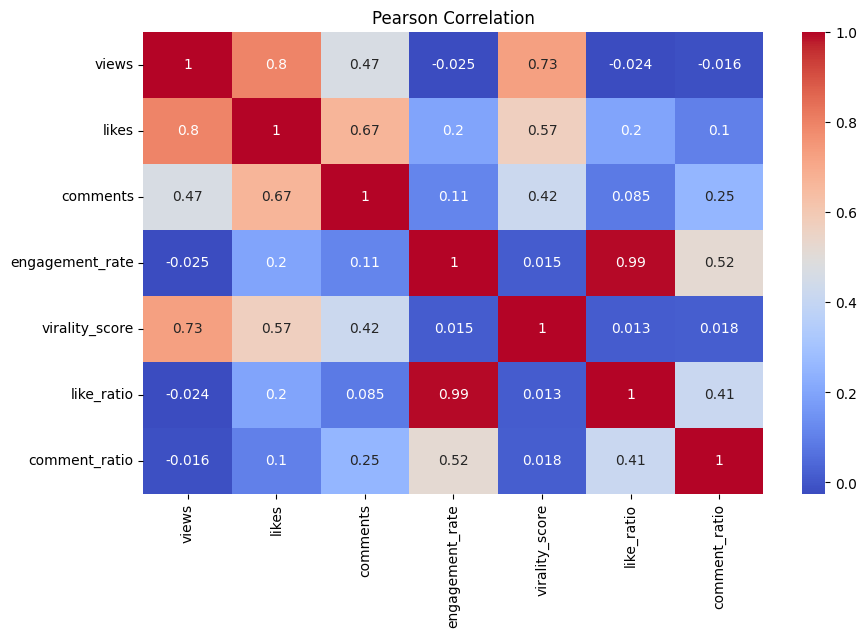

In [ ]:
num_cols = [
    'views','likes','comments',
    'engagement_rate','virality_score',
    'like_ratio','comment_ratio'
]

corr_matrix = df[num_cols].corr(method='pearson')

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation")
plt.show()

###Spearman Correlation

In [ ]:
spearman_corr = df[num_cols].corr(method='spearman')
print(spearman_corr)

                    views     likes  comments  engagement_rate  \
views            1.000000  0.810619  0.650994        -0.001209   
likes            0.810619  1.000000  0.743773         0.526187   
comments         0.650994  0.743773  1.000000         0.380063   
engagement_rate -0.001209  0.526187  0.380063         1.000000   
virality_score   0.856793  0.714144  0.561425         0.036692   
like_ratio       0.013347  0.540253  0.350821         0.995977   
comment_ratio   -0.159669  0.145876  0.576269         0.571449   

                 virality_score  like_ratio  comment_ratio  
views                  0.856793    0.013347      -0.159669  
likes                  0.714144    0.540253       0.145876  
comments               0.561425    0.350821       0.576269  
engagement_rate        0.036692    0.995977       0.571449  
virality_score         1.000000    0.049987      -0.127734  
like_ratio             0.049987    1.000000       0.513603  
comment_ratio         -0.127734    0.513603 

##03. Hypothesis Testing

###3.1 Weekend vs Weekday Engagement (T-Test)

In [ ]:


weekend = df[df['is_weekend'] == 1]['engagement_rate'].dropna()
weekday = df[df['is_weekend'] == 0]['engagement_rate'].dropna()

t_stat, p_value = stats.ttest_ind(weekend, weekday, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: -27.92412448522774
P-value: 1.802502388244571e-171


###3.2 Tags Impact on Views (T-Test)

In [ ]:
with_tags = df[df['has_tags'] == 1]['views']
without_tags = df[df['has_tags'] == 0]['views']

t_stat, p_value = stats.ttest_ind(with_tags, without_tags, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: -42.26608954975624
P-value: 0.0


###3.3 Exclamation Titles Impact (T-Test)

In [ ]:
exc = df[df['title_has_exclamation'] == 1]['views']
no_exc = df[df['title_has_exclamation'] == 0]['views']

t_stat, p_value = stats.ttest_ind(exc, no_exc, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: -26.87979217451209
P-value: 6.884323552764214e-159


##04. Regression Analysis

###Linear Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

features = [
    'views','likes','comments',
    'title_length','title_uppercase_ratio',
    'tag_count','has_tags','is_weekend'
]

X = df[features]
y = df['virality_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

importance = pd.Series(model.coef_, index=features).sort_values(ascending=False)
print(importance)

has_tags                 11051.557025
title_uppercase_ratio     5676.853999
tag_count                 1150.009913
title_length              1137.949676
comments                     5.834150
views                        0.236767
likes                       -1.050474
is_weekend              -54529.069938
dtype: float64


###Model Performance

In [ ]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.48403635885715524


##05. Distribution Testing

###Shapiro Test

In [ ]:
sample = df['engagement_rate'].dropna().sample(5000)

stat, p = stats.shapiro(sample)

print("Shapiro Stat:", stat)
print("P-value:", p)

Shapiro Stat: 0.8954228659897014
P-value: 5.757318898722599e-50


In [ ]:
df.shape

(1042384, 32)

In [ ]:
df.to_csv("/content/drive/MyDrive/DVA_Project/data/processed/statistical_dataset.csv", index=False)


##06. Key Statistical Conclusions

In [ ]:
df.shape

(1042384, 32)